<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

## Datos
El corpus de texto se formará a partir del libro La Metamorfosis de Franz Kafka.

### Lectura online

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/franz-kafka/la-metamorfosis/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [4]:
article_text[:1000]

' cuando gregorio samsa se despertó una mañana después de un sueño \nintranquilo, se encontró sobre su cama convertido en un monstruoso \ninsecto. estaba tumbado sobre su espalda dura, y en forma de caparazón \ny, al levantar un poco la cabeza veía un vientre abombado, parduzco, \ndividido por partes duras en forma de arco, sobre cuya protuberancia \napenas podía mantenerse el cobertor, a punto ya de resbalar al suelo. \nsus muchas patas, ridículamente pequeñas en comparación con el resto de \nsu tamaño, le vibraban desamparadas ante los ojos. «¿qué me ha ocurrido?», pensó. no era un sueño. su habitación, una auténtica habitación humana, si \nbien algo pequeña, permanecía tranquila entre las cuatro paredes harto \nconocidas. por encima de la mesa, sobre la que se encontraba extendido \nun muestrario de paños desempaquetados —samsa era viajante de comercio—,\n estaba colgado aquel cuadro que hacía poco había recortado de una \nrevista y había colocado en un bonito marco dorado. represen

### Limpieza de datos

In [5]:
# limpieza del texto
import re
import unicodedata

def limpieza_basica(text):
    # 1. Normalización Unicode (para manejar tildes y caracteres especiales uniformemente)
    text = unicodedata.normalize('NFKC', text)

    # 2. Se eliminan saltos de línea
    text = re.sub(r'\n', ' ', text)

    # 3. Se eliminan saltos de línea
    text = re.sub(r'«', ' ', text)

    # 4. Se eliminan caracteres especiales: « o »
    text = re.sub(r'«', ' ', text)
    text = re.sub(r'»', ' ', text)

    # 5. Limpieza de espacios en blanco múltiples
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

article_text = limpieza_basica(article_text)

In [6]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

'cuando gregorio samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto. estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya protuberancia apenas podía mantenerse el cobertor, a punto ya de resbalar al suelo. sus muchas patas, ridículamente pequeñas en comparación con el resto de su tamaño, le vibraban desamparadas ante los ojos. ¿qué me ha ocurrido? , pensó. no era un sueño. su habitación, una auténtica habitación humana, si bien algo pequeña, permanecía tranquila entre las cuatro paredes harto conocidas. por encima de la mesa, sobre la que se encontraba extendido un muestrario de paños desempaquetados —samsa era viajante de comercio—, estaba colgado aquel cuadro que hacía poco había recortado de una revista y había colocado en un bonito marco dorado. representaba a una dama ataviada c

In [7]:
len(article_text)

121387

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [8]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [9]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [10]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [11]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

55

In [12]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [13]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [14]:
tokenized_text[:50]

[48,
 8,
 5,
 38,
 10,
 44,
 11,
 37,
 46,
 27,
 37,
 44,
 46,
 45,
 44,
 11,
 34,
 5,
 39,
 34,
 5,
 11,
 34,
 27,
 11,
 10,
 27,
 34,
 9,
 27,
 46,
 12,
 24,
 11,
 8,
 38,
 5,
 11,
 39,
 5,
 47,
 5,
 38,
 5,
 11,
 10,
 27,
 34,
 9,
 8]

### Organizando y estructurando el dataset

Se mantiene la misma tokenización del ejemplo.

In [15]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [16]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [17]:
# Se aplicó corrección. La fórmula del ejemplo era la siguiente, que genera una lista con listas de longitud creciente de cero a num_val-1 (esto entiendo sería incorrecto)
# tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]

# Fórmula corregida. Listas de longitud max_context_size consecutivas.
tokenized_sentences_val = [
  val_text[init*max_context_size : (init+1)*max_context_size]
  for init in range(num_val)
]


In [18]:
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [19]:
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [20]:
X.shape

(109087, 100)

In [21]:
X[0,:10]

array([48,  8,  5, 38, 10, 44, 11, 37, 46, 27])

In [22]:
y[0,:10]

array([ 8,  5, 38, 10, 44, 11, 37, 46, 27, 37])

In [23]:
vocab_size = len(chars_vocab)

# Modelo baseline

In [24]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

Se toma el modelo original del ejemplo como baseline

In [25]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 55)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 200)      │        51,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 55)       │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,255 (243.18 KB)

 Trainable params: 62,255 (243.18 KB)

 Non-trainable params: 0 (0.00 B)


### Callback fin época

La callback está basada en la original, pero redefinida para consumir menos memoria (Colab no corría debido a falla por límite de memoria).

In [26]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
class PplCallbackStreaming(keras.callbacks.Callback):
    """
    Calcula perplejidad sobre validación al final de cada epoch sin
    materializar predicciones de gran tamaño en memoria.
    Implementa early stopping por perplejidad.
    """

    def __init__(self, val_data, history_ppl, patience=5, model_name='my_model.keras', batch_size=2048):
        self.val_data = val_data
        self.history_ppl = history_ppl
        self.patience = patience
        self.batch_size = batch_size
        self.model_name = model_name

        self.min_score = np.inf
        self.patience_counter = 0

        self.inputs = []
        self.targets = []

        for seq in self.val_data:
            # seq es una secuencia de tokens (ints)
            len_seq = len(seq)
            # subseqs: [seq[:1], seq[:2], ..., seq[:len_seq-1]]
            for i in range(1, len_seq):
                self.inputs.append(seq[:i])
                self.targets.append(seq[i])

        self.targets = np.array(self.targets, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        total_neg_log = 0.0
        total_count = 0

        n = len(self.targets)

        for start in range(0, n, self.batch_size):
            end = min(start + self.batch_size, n)

            batch_subseq = self.inputs[start:end]
            batch_x = pad_sequences(batch_subseq, maxlen=max_context_size, padding="pre")
            # tu modelo espera shape (batch, time, 1) porque usás input_shape=(None,1)
            batch_x = batch_x[..., None]

            preds = self.model.predict_on_batch(batch_x)  # (B, T, V)
            # Queremos prob del target en el último timestep
            last = preds[:, -1, :]  # (B, V)
            idx = self.targets[start:end]
            p = last[np.arange(end - start), idx]

            # Evitar log(0)
            p = np.clip(p, 1e-10, 1.0)
            total_neg_log += -np.sum(np.log(p))
            total_count += (end - start)

            # liberar refs
            del batch_x, preds, last, p

        current_score = float(np.exp(total_neg_log / total_count))
        self.history_ppl.append(current_score)
        print(f"\n mean perplexity: {current_score} \n")

        if current_score < self.min_score:
            self.min_score = current_score
            self.model.save(self.model_name)
            print("Saved new model!")
            self.patience_counter = 0
        else:
            self.patience_counter += 1
            if self.patience_counter == self.patience:
                print("Stopping training...")
                self.model.stop_training = True



### Entrenamiento

In [27]:
history_ppl_rnn = []
model_rnn_name = "model_rnn.keras"
hist = model.fit(
    X, y,
    epochs=20,
    callbacks=[PplCallbackStreaming(tokenized_sentences_val, history_ppl_rnn, patience=5, model_name = model_rnn_name, batch_size=2048)],
    batch_size=256
)

Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.5877
 mean perplexity: 7.728482246398926 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - loss: 2.2957
Epoch 2/20
424/427 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.9960
 mean perplexity: 6.568507671356201 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 1.9547
Epoch 3/20
424/427 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.8432
 mean perplexity: 5.856750965118408 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.8154
Epoch 4/20
425/427 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.7410
 mean perplexity: 5.486133098602295 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.7220
Epoch 5/20
423/427 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6744
 mean perplexity: 5.267289638519287 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 1.6616
Epoch 6/20
426/427 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.6280
 mean perplexity: 5.0873413085

In [28]:
best_epoch_rnn = np.argmin(history_ppl_rnn) + 1
best_ppl_rnn = np.min(history_ppl_rnn)
print(f"Best validation perplexity: {best_ppl_rnn:.2f}")

Best validation perplexity: 4.51


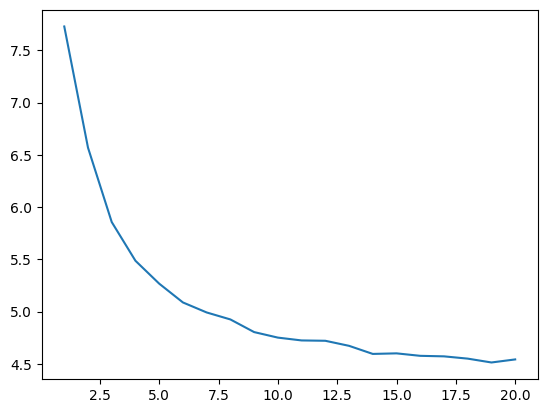

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(history_ppl_rnn) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl_rnn)
plt.show()

In [30]:
# Cargamos el mejor modelo guardado del entrenamiento para hacer inferencia
model_rnn = keras.models.load_model(model_rnn_name)


### Predicción del próximo caracter

In [31]:
# Se puede usar gradio para probar el modelo
# Gradio es una herramienta muy útil para crear interfaces para ensayar modelos
# https://gradio.app/

!pip install -q gradio

In [32]:
# import gradio as gr

# def model_response(human_text):

#     # Encodeamos
#     encoded = [char2idx[ch] for ch in human_text.lower() ]
#     # Si tienen distinto largo
#     encoded = pad_sequences([encoded], maxlen=max_context_size, padding='pre')

#     # Predicción softmax
#     y_hat = np.argmax(model_rnn.predict(encoded)[0,-1,:])


#     # Debemos buscar en el vocabulario el caracter
#     # que corresopnde al indice (y_hat) predicho por le modelo
#     out_word = ''
#     out_word = idx2char[y_hat]

#     # Agrego la palabra a la frase predicha
#     return human_text + out_word

# iface = gr.Interface(
#     fn=model_response,
#     inputs=["textbox"],
#     outputs="text")

# iface.launch(debug=True)

### Generación de secuencias

In [33]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

In [34]:
input_text='dirigía sus ojos lo más agudamente posible hacia la'

In [35]:
generate_seq(model_rnn, input_text, max_length=max_context_size, n_words=30)

'dirigía sus ojos lo más agudamente posible hacia la madre y la cabeza de la cabez'

###  Beam search y muestreo aleatorio

In [36]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [37]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [68]:
# predicción con beam search
salidas = beam_search(model,num_beams=10,num_words=30,input=input_text)

In [69]:
salidas[0]

array([10, 45, 46, 45, 37, 16,  5, 11, 34,  8, 34, 11, 44, 18, 44, 34, 11,
       31, 44, 11, 39, 19, 34, 11,  5, 37,  8, 10,  5, 39, 27, 38, 12, 27,
       11,  9, 44, 34, 45, 32, 31, 27, 11,  0,  5, 48, 45,  5, 11, 31,  5,
       11,  0,  5, 32, 45, 12,  5, 48, 45, 24, 38, 11, 10, 27, 11, 37, 46,
       27, 37, 44, 46, 45, 44, 11,  0,  5, 32, 16,  5, 11])

In [70]:
# veamos las salidas
decode(salidas[0])

'dirigía sus ojos lo más agudamente posible hacia la habitación de gregorio había '

# Modelo 2: LSTM

En esta sección se entrena un modelo de lenguaje por caracteres basado en LSTM, manteniendo el mismo dataset, contexto y métrica de evaluación (perplejidad sobre validación).

Para el modelo LSTM, se incluyó una capa de embeddings para mejorar el rendimiento. Se realizó una prueba con OHE pero los resultados era peores que la RNN.

## Definición del modelo

In [41]:
from keras.models import Sequential
from keras.layers import Input, TimeDistributed, CategoryEncoding, LSTM, Dense, Embedding

In [42]:
model_lstm = Sequential(name="char_lstm_emb")

model_lstm.add(Input(shape=(None,)))

model_lstm.add(Embedding(
    input_dim=vocab_size,
    output_dim=64
))

model_lstm.add(LSTM(
    256,
    return_sequences=True,
    dropout=0.2,
    recurrent_dropout=0.2
))

model_lstm.add(Dense(vocab_size, activation="softmax"))

model_lstm.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop"
)

model_lstm.summary()

Model: "char_lstm_emb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 55)       │        14,135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,359 (1.32 MB)

 Trainable params: 346,359 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [43]:
history_ppl_lstm = []
model_lstm_name = "model_lstm.keras"

In [44]:
hist_lstm = model_lstm.fit(
    X, y,
    epochs=20,
    callbacks=[
        PplCallbackStreaming(
            tokenized_sentences_val,
            history_ppl_lstm,
            patience=5,
            model_name=model_lstm_name,
            batch_size=2048
        )
    ],
    batch_size=256
)

Epoch 1/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 2.7004
 mean perplexity: 12.906965255737305 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 153s 343ms/step - loss: 2.3804
Epoch 2/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 1.9844
 mean perplexity: 9.475813865661621 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 145s 341ms/step - loss: 1.9266
Epoch 3/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 1.7874
 mean perplexity: 7.967256546020508 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 146s 341ms/step - loss: 1.7552
Epoch 4/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - loss: 1.6695
 mean perplexity: 5.704120635986328 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 146s 341ms/step - loss: 1.6457
Epoch 5/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 1.5815
 mean perplexity: 5.307583808898926 

Saved new model!
427/427 ━━━━━━━━━━━━━━━━━━━━ 145s 340ms/step - loss: 1.5625
Epoch 6/20
427/427 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - loss: 1.5123
 mean perp

## Evaluación de perplejidad

In [45]:
best_epoch_lstm = np.argmin(history_ppl_lstm) + 1
best_ppl_lstm = np.min(history_ppl_lstm)

print(f"Best epoch (LSTM): {best_epoch_lstm}")
print(f"Best validation perplexity (LSTM): {best_ppl_lstm:.2f}")

Best epoch (LSTM): 19
Best validation perplexity (LSTM): 4.30


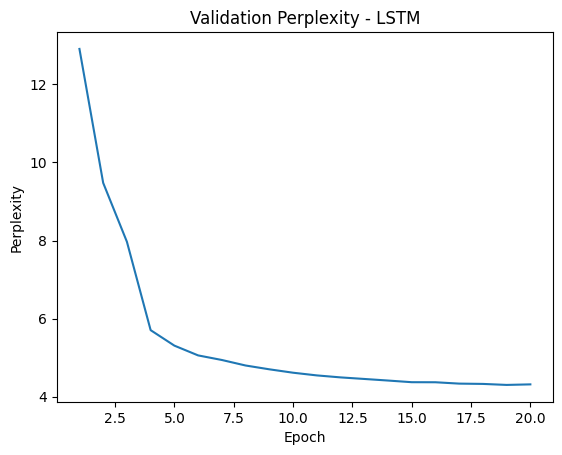

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

epoch_count_lstm = range(1, len(history_ppl_lstm) + 1)
sns.lineplot(x=epoch_count_lstm, y=history_ppl_lstm)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity - LSTM")
plt.show()

## Comparación de perplejidad con RNN
Puede verse que los valores de perplejidad obtenidos son similares a la RNN simple, pero la red LSTM comienza a mejorar levemente aproximadamente a partir de la época 8. Esta mejora, si bien es leve, es sostenida a lo largo de las épocas posteriores, por lo que indica un mejor rendimiento del modelo.

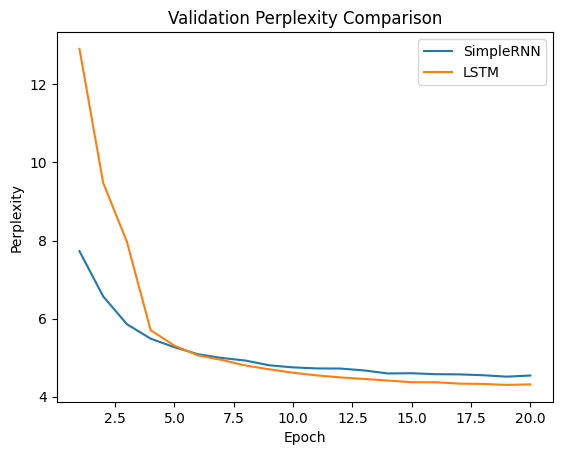

In [47]:
epoch_count_rnn  = range(1, len(history_ppl_rnn)  + 1)
epoch_count_lstm = range(1, len(history_ppl_lstm) + 1)

sns.lineplot(x=epoch_count_rnn,  y=history_ppl_rnn,  label="SimpleRNN")
sns.lineplot(x=epoch_count_lstm, y=history_ppl_lstm, label="LSTM")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity Comparison")
plt.show()

## Generación de secuencias

In [48]:
model_lstm_best = keras.models.load_model(model_lstm_name)

Greedy Search

In [71]:
generate_seq(model_lstm_best, input_text, max_length=max_context_size, n_words=30)

'dirigía sus ojos lo más agudamente posible hacia la madre y la hermana se abrió l'

Beam Search

In [72]:
# Temperatura 1
salidas_bs_lst_1 = beam_search(model_lstm_best,num_beams=10,num_words=30,input=input_text)

In [73]:
decode(salidas_bs_lst_1[0])

'dirigía sus ojos lo más agudamente posible hacia la habitación de gregorio, pero '

In [74]:
# Temperatura 2
salidas_bs_lst_2 = beam_search(model_lstm_best,num_beams=10,num_words=30, temp=4, input=input_text)

In [75]:
decode(salidas_bs_lst_2[0])

'dirigía sus ojos lo más agudamente posible hacia la habitación de gregorio, pero '

In [80]:
# Temperatura 3
salidas_bs_lst_3 = beam_search(model_lstm_best,num_beams=10,num_words=30, temp=8, input=input_text)

In [81]:
decode(salidas_bs_lst_3[0])

'dirigía sus ojos lo más agudamente posible hacia la habitación de gregorio, pero '

De las pruebas de generación de secuencias, puede verse que los resultados obtenidos mediante el modelo RNN simple y el modelo LSTM son de calidad similar. La secuencia contiene palabras del español válidas y además conserva cierto sentido con la frase utilizada como entrada.

En el caso de Beam Search del LSTM, se esperaba obtener distintos resultados al variar la temperatura, pero en todos los casos devolvió la misma secuencia.